# 06 · La cascada del GTFS sobre un autobús real

Los cinco notebooks anteriores describen **fuentes**. Este describe un **método**: cómo
se pasa de una posición GPS suelta a un número de segundos de retraso, recorriendo el
GTFS estático de la EMT paso a paso sobre un autobús concreto de un día concreto.

La pregunta que contesta es la que hace todo el mundo al oír el tema del TFM: *¿y cómo
sabes tú que ese autobús va tarde?* La respuesta corta es una resta:

$$\text{retraso}(p) \;=\; t_{\text{paso observado}}(p) \;-\; t_{\text{llegada programada}}(p)$$

La respuesta larga es que la EMT no publica **ninguno** de los dos términos, y este
notebook es la reconstrucción de ambos.

## Qué se ejecuta aquí

| paso | fichero del GTFS | qué aporta |
|------|------------------|------------|
| 1 | `calendar` + `calendar_dates` | qué viajes circulaban ese día |
| 2 | `routes` + `trips` | qué viajes existen de esa línea y ese sentido |
| 3 | `shapes` | el eje sobre el que se mide el avance |
| 4 | `stops` + `stop_times` | dónde está cada parada en ese eje |
| 5 | — | el cruce observado, interpolado entre dos posiciones |
| 6 | `stop_times` | la resta |

## Caso elegido

**Línea 31** (La Patacona → Estació Joaquín Sorolla), **miércoles 26/08/2026**, un
vehículo que sale de cabecera a las 15:05 hora local.

Las tres condiciones no son arbitrarias:

- **Línea 31** porque tiene un solo `route_id`. Tres líneas del feed (`73`, `C2`, `C3`)
  repiten `route_short_name` con dos `route_id` distintos, y la capa en vivo solo
  publica el número de línea: son ambiguas de entrada.
- **26/08** porque cae **dentro** de la vigencia declarada del feed (`feed_start_date`
  = 20260824). Los días 15–23/08 de la captura quedan fuera de esa ventana y arrastran
  un supuesto que contaminaría la demostración.
- **Fuera de hora punta** porque la asignación de viaje —el paso frágil— es inequívoca
  cuando los viajes van cada 10 min y ambigua cuando van cada 4.

> **Aviso de resultado.** El paso 3 destapa que `shape_dist_traveled`, el campo que
> parecía regalar el trabajo geométrico hecho, **no contiene geometría**: es el horario
> reescalado. Usarlo habría producido retrasos estructuralmente nulos sin lanzar ni un
> error. Está medido abajo, con su $R^2$.

In [1]:
from __future__ import annotations

import io
import sys
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# El notebook corre desde notebooks/EDA/ o desde la raíz del repo.
RAIZ = Path.cwd()
while not (RAIZ / "pyproject.toml").exists():
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ / "src"))
sys.path.insert(0, str(RAIZ / "notebooks" / "EDA"))

from eda_utils import PALETA, estilo  # noqa: E402
from project.analysis.diagnose import a_metros  # noqa: E402
from project.tracking import rastrear  # noqa: E402

estilo()

GTFS = RAIZ / "data" / "raw" / "gtfs" / "emt_google_transit.zip"
DIA = pd.Timestamp("2026-08-26")
LINEA = "31"
SENTIDO = "La Patacona - Est.J.Sorolla"
TZ = "Europe/Madrid"

z = zipfile.ZipFile(GTFS)
gtfs = lambda n, **k: pd.read_csv(io.TextIOWrapper(z.open(n), "utf-8"), **k)  # noqa: E731

print(f"GTFS: {GTFS.relative_to(RAIZ)}  ({GTFS.stat().st_size:,} B)")
gtfs("feed_info.txt").T

GTFS: data\raw\gtfs\emt_google_transit.zip  (7,161,519 B)


,0
feed_publisher_name,EMT Valencia
feed_publisher_url,https://www.emtvalencia.es
feed_lang,ca
default_lang,en
feed_start_date,20260824
feed_end_date,20260930
feed_version,01-09-2026
feed_contact_email,atencioalaciutadania@emtvalencia.es
feed_contact_url,https://www.emtvalencia.es


El feed se publicó el 01/09/2026 y declara vigencia del 24/08 al 30/09. La captura de
autobuses va del 15/08 al 31/08: **nueve de los diecisiete días quedan antes de
`feed_start_date`**, aunque `calendar.txt` afirme validez desde el 15/08. Por eso el
día elegido es el 26.

---

## 1 · Calendario: qué circulaba ese miércoles

`calendar.txt` da el patrón semanal de cada `service_id` y `calendar_dates.txt` lo
corrige con excepciones: `exception_type = 1` añade un servicio ese día, `2` lo quita.
Saltarse este paso mete horarios de laborable en festivo, y el retraso sale disparado
sin que nada avise.

In [2]:
ymd = DIA.strftime("%Y%m%d")
dow = ["monday", "tuesday", "wednesday", "thursday", "friday", "saturday", "sunday"][DIA.dayofweek]

cal = gtfs("calendar.txt", dtype={"start_date": str, "end_date": str})
cdt = gtfs("calendar_dates.txt", dtype={"date": str})

activos = set(cal[(cal.start_date <= ymd) & (cal.end_date >= ymd) & (cal[dow] == 1)].service_id)
exc = cdt[cdt.date == ymd]
activos |= set(exc[exc.exception_type == 1].service_id)
activos -= set(exc[exc.exception_type == 2].service_id)

print(f"{ymd} ({dow})")
print(f"  service_id en calendar.txt          : {len(cal)}")
print(f"  activos por patrón semanal          : {len(activos)}")
print(f"  excepciones de calendar_dates ese día: {len(exc)}")

20260826 (wednesday)
  service_id en calendar.txt          : 281
  activos por patrón semanal          : 45
  excepciones de calendar_dates ese día: 0


## 2 · De «línea 31» a una lista de viajes

La capa en vivo publica `linea = "31"`. El GTFS trabaja con `route_id`, que es interno.
`routes.txt` traduce; `trips.txt` expande esa ruta en las pasadas concretas del día.

Aquí aparece el primer desajuste entre las dos fuentes: **`trips.txt` no trae
`direction_id`**. El sentido hay que deducirlo del `shape_id` o del `trip_headsign`, y
casarlo con el campo `trayecto` de la EMT, que está escrito de otra forma y en otro
idioma.

In [3]:
routes = gtfs("routes.txt", dtype=str)
trips = gtfs("trips.txt", dtype=str)

rid = routes[routes.route_short_name == LINEA].route_id.tolist()
hoy = trips[(trips.route_id.isin(rid)) & (trips.service_id.isin(activos))]

print(f"linea {LINEA}  ->  route_id {rid}")
print(f"  {routes[routes.route_id.isin(rid)].route_long_name.iloc[0]}")
print(f"  viajes en el feed : {len(trips[trips.route_id.isin(rid)]):>5}")
print(f"  viajes ESE día    : {len(hoy):>5}")
print()
print(hoy.groupby(["shape_id", "trip_headsign"]).size().rename("viajes").to_frame())

linea 31  ->  route_id ['1053']
  31 - LA PATACONA/LA MALVA-ROSA - EST. J. SOROLLA
  viajes en el feed :   603
  viajes ESE día    :   194

                                        viajes
shape_id       trip_headsign                  
1053_2248_2284 Estació Joaquín Sorolla      99
1053_2284_2248 La Patacona - Institut       95


Dos `shape_id`, uno por sentido. El `trip_headsign` es el **destino**
(`Estació Joaquín Sorolla`), mientras que el `trayecto` de la EMT es
**origen - destino** (`La Patacona - Est.J.Sorolla`). No hay clave común: el
emparejamiento es por texto, o —como se hace más abajo— por geometría, que es más
robusto.

---

## 3 · La geometría, y la trampa de `shape_dist_traveled`

`stop_times.txt` trae `shape_dist_traveled` **poblado en el 100 % de sus 845.736
filas**. A primera vista es un regalo: la abscisa curvilínea de cada parada ya
calculada, sin tener que proyectar nada.

La primera comprobación que se le hace a un regalo así es si cuadra con la geometría
que lo acompaña.

In [4]:
from project.ingest.sources import haversine_m

shapes = gtfs("shapes.txt")

filas = []
for sid, g in shapes.groupby("shape_id"):
    g = g.sort_values("shape_pt_sequence")
    la, lo = g.shape_pt_lat.to_numpy(), g.shape_pt_lon.to_numpy()
    real = haversine_m(la[:-1], lo[:-1], la[1:], lo[1:]).sum()
    filas.append((sid, len(g), real, g.shape_dist_traveled.max()))

comp = pd.DataFrame(filas, columns=["shape_id", "puntos", "largo_real_m", "declarado"])
comp["ratio"] = comp.declarado / comp.largo_real_m

print(f"shapes en el feed: {len(comp)}")
print(f"con ratio declarado/real dentro de ±5 %: {int(comp.ratio.between(0.95, 1.05).sum())}")
print()
print(comp.ratio.describe().round(3).to_frame().T)

shapes en el feed: 95
con ratio declarado/real dentro de ±5 %: 0

       count  mean   std   min   25%   50%   75%   max
ratio 95.000 2.994 0.536 1.649 2.700 2.984 3.382 4.247


**Ninguno de los 95.** El cociente entre lo declarado y la longitud real de la propia
polilínea va de 1,65 a 4,25, con mediana 2,98. No es un cambio de unidad: un factor de
conversión sería constante.

Si no es distancia, ¿qué es? La pista está en que dentro de un mismo viaje el cociente
**crece** conforme avanza el recorrido. Eso pasa cuando la magnitud no crece con el
espacio sino con el tiempo, porque el autobús va más despacio al final.

In [5]:
def a_segundos(hhmmss: str) -> int:
    """GTFS usa tiempo de servicio: '25:10:00' es legal y significa la 1:10 del día
    siguiente. Por eso no se puede parsear con `pd.to_datetime`."""
    h, m, s = hhmmss.split(":")
    return int(h) * 3600 + int(m) * 60 + int(s)


st = gtfs("stop_times.txt", dtype=str)
st["t"] = st.arrival_time.map(a_segundos)
st["stop_sequence"] = st.stop_sequence.astype(int)
st["sdt"] = st.shape_dist_traveled.astype(float)
st["dt"] = st.t - st.groupby("trip_id")["t"].transform("min")

muestra = st[st.trip_id.isin(pd.Series(st.trip_id.unique()).sample(300, random_state=0))]
r2 = muestra[muestra.dt > 0].groupby("trip_id").apply(
    lambda g: np.corrcoef(g.dt, g.sdt)[0, 1] ** 2, include_groups=False
)

print(f"R² de shape_dist_traveled ~ segundos programados, en {len(r2)} viajes")
print(f"  mínimo  : {r2.min():.6f}")
print(f"  mediana : {r2.median():.6f}")
print(f"  viajes con R² > 0.9999 : {int((r2 > 0.9999).sum())} de {len(r2)}")

R² de shape_dist_traveled ~ segundos programados, en 300 viajes
  mínimo  : 0.999997
  mediana : 1.000000
  viajes con R² > 0.9999 : 300 de 300


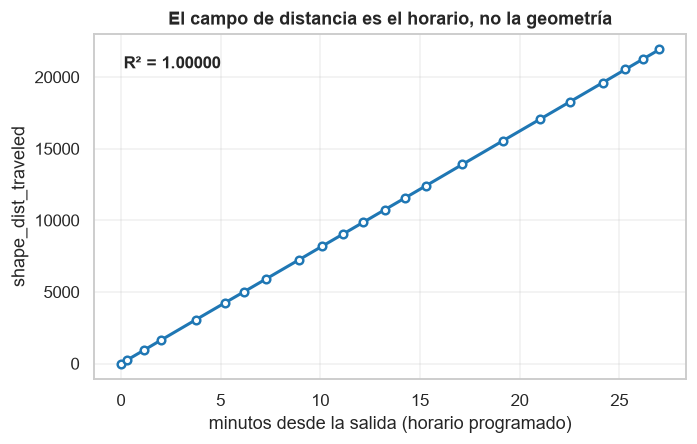

In [6]:
tid_demo = st[st.trip_id == st.trip_id.iloc[0]]
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(
    tid_demo.dt / 60,
    tid_demo.sdt,
    marker="o",
    ms=5,
    lw=2,
    color=PALETA["emt_buses"],
    mfc="white",
    mew=1.6,
)
ax.set_xlabel("minutos desde la salida (horario programado)")
ax.set_ylabel("shape_dist_traveled")
ax.set_title("El campo de distancia es el horario, no la geometría")
ax.annotate(
    f"R² = {np.corrcoef(tid_demo.dt, tid_demo.sdt)[0, 1] ** 2:.5f}",
    xy=(0.05, 0.9),
    xycoords="axes fraction",
    fontsize=11,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

**$R^2 = 1{,}000000$ en los 300 viajes de la muestra.** `shape_dist_traveled` es una
función lineal exacta del tiempo programado dentro de cada viaje, con una constante
distinta por viaje (entre 6,7 y 20,5 unidades por segundo). No aporta ni un bit de
información geométrica.

**Consecuencia si se usa sin mirar:** el eje sobre el que se interpola el paso del
autobús *sería el propio horario*. Se estaría midiendo el horario contra sí mismo, el
retraso saldría estructuralmente pegado a cero, y no habría excepción, ni aviso, ni
nada raro en las gráficas. Es el patrón exacto de la trampa 004: el instrumento miente
y el resultado parece bueno.

**Decisión: se ignora el campo y se recalcula la abscisa** proyectando cada punto sobre
la polilínea. La geometría de `shapes.txt` sí es buena, como se comprueba a
continuación.

In [7]:
def eje(shape_id: str):
    """Polilínea de un shape en metros locales, con su longitud acumulada."""
    g = shapes[shapes.shape_id == shape_id].sort_values("shape_pt_sequence")
    x, y = a_metros(g.shape_pt_lat.to_numpy(), g.shape_pt_lon.to_numpy())
    P = np.stack([x, y], axis=1)
    segs = np.stack([P[:-1], P[1:]], axis=1)
    largo = np.sqrt(((P[1:] - P[:-1]) ** 2).sum(axis=1))
    return segs, np.concatenate([[0.0], np.cumsum(largo)]), largo


def proyectar(segs, acum, largo, lat, lon):
    """Abscisa curvilínea (m desde cabecera) y distancia al trazado, por punto."""
    qx, qy = a_metros(np.asarray(lat, float), np.asarray(lon, float))
    a, b = segs[:, 0, :], segs[:, 1, :]
    ab = b - a
    L2 = (ab**2).sum(axis=1)
    L2[L2 == 0] = 1e-9
    apx = qx[:, None] - a[None, :, 0]
    apy = qy[:, None] - a[None, :, 1]
    t = np.clip((apx * ab[None, :, 0] + apy * ab[None, :, 1]) / L2[None, :], 0.0, 1.0)
    D = np.sqrt((apx - t * ab[None, :, 0]) ** 2 + (apy - t * ab[None, :, 1]) ** 2)
    i = D.argmin(axis=1)
    j = np.arange(len(qx))
    return acum[i] + t[j, i] * largo[i], D[j, i]

### Las paradas del sentido elegido, colocadas sobre el eje

El patrón de paradas es el mismo para todos los viajes de un `shape_id`, así que basta
tomar uno cualquiera. La comprobación que importa: **la distancia de cada parada al
trazado**. Si las paradas no caen sobre la polilínea, la geometría no sirve y todo lo
que venga después es ruido.

In [8]:
SHAPE = "1053_2248_2284"  # La Patacona -> Estació Joaquín Sorolla
segs, acum, largo = eje(SHAPE)

stops = gtfs("stops.txt").astype({"stop_id": str})
tid_patron = trips[trips.shape_id == SHAPE].trip_id.iloc[0]

paradas = (
    st[st.trip_id == tid_patron]
    .sort_values("stop_sequence")
    .merge(stops[["stop_id", "stop_name", "stop_lat", "stop_lon"]], on="stop_id", how="left")
)
paradas["s_m"], paradas["d_traza_m"] = proyectar(
    segs, acum, largo, paradas.stop_lat, paradas.stop_lon
)

print(f"shape {SHAPE}: {len(acum)} puntos, {acum[-1]:,.0f} m de recorrido real")
print(f"paradas: {len(paradas)}")
print(f"distancia parada -> trazado:  p50 {paradas.d_traza_m.median():.1f} m   "
      f"p90 {paradas.d_traza_m.quantile(0.9):.1f} m   max {paradas.d_traza_m.max():.1f} m")
print(f"abscisa estrictamente creciente: {paradas.s_m.is_monotonic_increasing}")
print()
print(
    paradas[["stop_sequence", "stop_name", "arrival_time", "sdt", "s_m", "d_traza_m"]]
    .head(8)
    .to_string(index=False)
)

shape 1053_2248_2284: 343 puntos, 9,776 m de recorrido real
paradas: 34
distancia parada -> trazado:  p50 3.4 m   p90 8.2 m   max 15.1 m
abscisa estrictamente creciente: True

 stop_sequence                         stop_name arrival_time       sdt       s_m  d_traza_m
             1            La Patacona - Institut     06:00:00     0.000     0.161      2.484
             2       Blasco Ibáñez - Mar Tirreno     06:00:46   586.280   574.309      8.996
             3 Blasco Ibáñez - Arnau de Vilanova     06:01:48 1,381.930   867.237      1.198
             4       La Malva-rosa - Mendizábal      06:03:25 2,628.690 1,086.459      3.110
             5    La Malva-rosa - Fuerteventura      06:04:28 3,431.000 1,385.968      8.488
             6  La Malva-rosa - Sant Joan de Déu     06:05:39 4,338.910 1,791.072      2.821
             7         La Malva-rosa - Riu Tajo      06:06:32 5,010.820 1,953.576      2.509
             8                   Reina - Remunta     06:08:10 6,262.800 2,195.33

Mediana de **3,4 m** y máximo de **15,1 m**: las 34 paradas caen sobre el trazado. La
geometría del feed es correcta; lo único roto era el campo de distancia.

Nótese la última comparación en la tabla: `sdt` llega a 30.695 en la parada final,
mientras la abscisa real es 9.776 m. Tres veces más, por lo ya visto.

---

## 4 · La trayectoria observada

Aquí entra `tracking.py`. La capa de la EMT no publica identificador de vehículo —`gid`
es un autoincrement que se reinicia en cada refresco— así que la identidad se
reconstruye emparejando snapshots consecutivos con asignación húngara, restringida a la
misma (línea, trayecto) y con una puerta física de velocidad.

In [9]:
ficheros = sorted((RAIZ / "data" / "curated" / f"source=emt_buses" / f"date={DIA:%Y-%m-%d}").glob("*.parquet"))
dia = pd.concat([pd.read_parquet(f) for f in ficheros], ignore_index=True)
dia = dia[dia.linea == LINEA]

print(f"{DIA:%Y-%m-%d}, línea {LINEA}: {len(dia):,} posiciones en {dia.snapshot_id.nunique():,} snapshots")
print(f"convención horaria en origen: {dia.tz_convencion.value_counts().to_dict()}")

seguido = rastrear(dia, predictivo=True)
seguido = seguido[seguido.trayecto == SENTIDO]
print(f"trayectorias reconstruidas en el sentido elegido: {seguido.vehicle_id.nunique()}")

2026-08-26, línea 31: 23,947 posiciones en 2,402 snapshots
convención horaria en origen: {'LOCAL_NAIVE': 19528, 'YA_EN_UTC': 4419}


trayectorias reconstruidas en el sentido elegido: 157


La columna `tz_convencion` merece una parada. La EMT **alterna** entre UTC y hora local
naive de un sondeo al siguiente: ese mismo día, 305.027 posiciones vienen en local y
73.578 ya en UTC. Como el retraso es una resta de tiempos, dos horas de desfase en una
parte de las filas produciría retrasos perfectamente creíbles y completamente falsos.
La capa `curated/` ya lo normaliza y deja constancia por fila (trampa 002).

In [10]:
resumen = seguido.groupby("vehicle_id").agg(n=("ts_utc", "size"), t0=("ts_utc", "min"))
resumen["salida_local"] = resumen.t0.dt.tz_convert(TZ)
resumen["hora"] = resumen.salida_local.dt.hour

fuera_de_punta = resumen[(resumen.n >= 60) & (resumen.hora.between(14, 15))]
VEHICULO = fuera_de_punta.n.idxmax()

via = seguido[seguido.vehicle_id == VEHICULO].sort_values("ts_utc").reset_index(drop=True)
via["s_m"], via["d_traza_m"] = proyectar(segs, acum, largo, via.lat, via.lon)
via["local"] = via.ts_utc.dt.tz_convert(TZ)

print(f"vehículo {VEHICULO}: {len(via)} posiciones")
print(f"  ventana        : {via.local.min():%H:%M:%S} -> {via.local.max():%H:%M:%S} local")
print(f"  cadencia mediana: {via.ts_utc.diff().dt.total_seconds().median():.0f} s")
print(f"  dist al trazado : p50 {via.d_traza_m.median():.1f} m   max {via.d_traza_m.max():.1f} m")
print(f"  avance          : {via.s_m.min():,.0f} -> {via.s_m.max():,.0f} m  (recorrido {acum[-1]:,.0f} m)")

vehículo v00178: 182 posiciones
  ventana        : 14:21:42 -> 15:55:13 local
  cadencia mediana: 30 s
  dist al trazado : p50 1.8 m   max 14.7 m
  avance          : 87 -> 9,621 m  (recorrido 9,776 m)


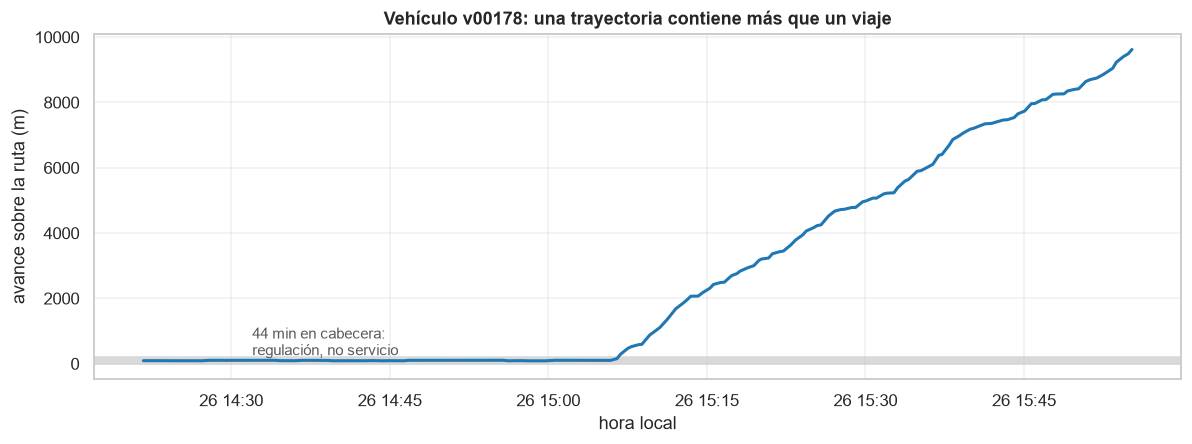

In [11]:
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(via.local, via.s_m, lw=2, color=PALETA["emt_buses"])
ax.axhspan(0, 200, color="0.85", zorder=0)
ax.annotate(
    "44 min en cabecera:\nregulación, no servicio",
    xy=(via.local.iloc[20], 260),
    fontsize=10,
    color="0.35",
)
ax.set_ylabel("avance sobre la ruta (m)")
ax.set_xlabel("hora local")
ax.set_title(f"Vehículo {VEHICULO}: una trayectoria contiene más que un viaje")
plt.tight_layout()
plt.show()

**Trayectoria ≠ viaje.** El vehículo está 44 minutos parado en cabecera antes de salir:
regulación entre servicios. La identidad del vehículo se mantiene, pero el viaje
programado contra el que hay que comparar empieza a las 15:05, no a las 14:21.
Segmentar la trayectoria en viajes es un paso propio, no un subproducto del tracking.

La abscisa tiene 44 retrocesos sobre 181 pasos, de hasta 15,8 m: es el ruido del GPS
mientras el autobús está parado. Se absorbe con un máximo acumulado —un autobús en
servicio no desanda la ruta— antes de interpolar.

---

## 5 · El cruce por parada

Con la cadencia de sondeo (~30 s) el autobús **se salta paradas enteras entre dos
muestras**: a 30 km/h recorre 250 m, y hay paradas a menos de esa distancia. Por eso no
vale «la posición más cercana a la parada»: hay que localizar las dos posiciones que
encierran la abscisa de la parada e **interpolar el instante** del cruce.

In [12]:
s = np.maximum.accumulate(via.s_m.to_numpy())          # el autobús no retrocede
t = via.ts_utc.astype("int64").to_numpy() / 1e9

cruces = []
for s_parada in paradas.s_m:
    k = np.searchsorted(s, s_parada)
    if k == 0 or k >= len(s):          # la parada queda fuera del tramo observado
        cruces.append(np.nan)
        continue
    ds = s[k] - s[k - 1]
    frac = 0.0 if ds == 0 else (s_parada - s[k - 1]) / ds
    cruces.append(t[k - 1] + frac * (t[k] - t[k - 1]))

paradas["t_obs"] = pd.to_datetime(pd.Series(cruces), unit="s", utc=True).dt.tz_convert(TZ)
print(f"paradas con cruce observado: {int(paradas.t_obs.notna().sum())} de {len(paradas)}")

paradas con cruce observado: 32 de 34


Dos paradas se quedan sin cruce, y las dos por una razón legítima: la primera porque el
autobús estaba estacionado *más allá* de ella durante la regulación, y la última porque
la trayectoria se corta 155 m antes del final. No se inventan: quedan nulas.

---

## 6 · Asignación de viaje: el paso frágil

Ya hay hora de paso observada. Falta contra **qué** viaje compararla, y la fuente no
publica `trip_id`. Se busca, entre los viajes de esa línea, sentido y día, el que
programa el paso más cerca de lo observado en la primera parada con cruce.

Un error aquí no produce un error pequeño: mete el desfase de un intervalo entero, con
aspecto de retraso normal. Por eso lo que se mira no es solo cuál gana, sino **por
cuánto**.

In [13]:
ref = paradas[paradas.t_obs.notna()].iloc[0]
obs_s = ref.t_obs.hour * 3600 + ref.t_obs.minute * 60 + ref.t_obs.second

candidatos = st[(st.trip_id.isin(hoy[hoy.shape_id == SHAPE].trip_id)) & (st.stop_id == ref.stop_id)].copy()
candidatos["desfase_s"] = (candidatos.t - obs_s).abs()
candidatos = candidatos.sort_values("desfase_s")

print(f"parada de referencia: {ref.stop_name}  (seq {ref.stop_sequence:.0f}, s = {ref.s_m:,.0f} m)")
print(f"paso observado      : {ref.t_obs:%H:%M:%S} local\n")
print(candidatos[["trip_id", "arrival_time", "desfase_s"]].head(4).to_string(index=False))

margen = candidatos.desfase_s.iloc[1] - candidatos.desfase_s.iloc[0]
VIAJE = candidatos.trip_id.iloc[0]
print(f"\nelegido {VIAJE}")
print(f"margen sobre el segundo candidato: {margen:.0f} s")

parada de referencia: Blasco Ibáñez - Mar Tirreno  (seq 2, s = 574 m)
paso observado      : 15:08:26 local

                    trip_id arrival_time  desfase_s
31_1053_601_2248_2284_2_056     15:06:57         89
31_1053_601_2248_2284_2_057     15:16:56        510
31_1053_601_2248_2284_2_055     14:56:58        688
31_1053_601_2248_2284_2_058     15:25:58       1052

elegido 31_1053_601_2248_2284_2_056
margen sobre el segundo candidato: 421 s


Ganador a 89 s del paso observado, siguiente a 510 s: **421 s de margen**. Inequívoco.

Ese margen es exactamente la magnitud que se estrecha en hora punta. Con intervalos de
4 minutos el margen cae a decenas de segundos y la asignación deja de ser segura: es el
riesgo abierto de este método, y la razón de haber elegido un caso de tarde.

---

## 7 · La resta

In [14]:
prog = (
    st[st.trip_id == VIAJE][["stop_sequence", "arrival_time", "t"]]
    .rename(columns={"arrival_time": "programado", "t": "prog_s"})
)
res = paradas[["stop_sequence", "stop_name", "s_m", "t_obs"]].merge(prog, on="stop_sequence", how="left")
res["obs_s"] = res.t_obs.dt.hour * 3600 + res.t_obs.dt.minute * 60 + res.t_obs.dt.second
res["retraso_s"] = res.obs_s - res.prog_s

vis = res.copy()
vis["observado"] = vis.t_obs.dt.strftime("%H:%M:%S").fillna("—")
vis["retraso"] = vis.retraso_s.map(lambda v: "—" if pd.isna(v) else f"{v:+.0f} s")
print(vis[["stop_sequence", "stop_name", "programado", "observado", "retraso"]].to_string(index=False))

v = res.retraso_s.dropna()
print(f"\nmediana {v.median():+.0f} s   |   rango {v.min():+.0f} a {v.max():+.0f} s   |   {len(v)}/{len(res)} paradas")

 stop_sequence                                  stop_name programado observado retraso
             1                     La Patacona - Institut   15:06:00         —       —
             2                Blasco Ibáñez - Mar Tirreno   15:06:57  15:08:26   +89 s
             3          Blasco Ibáñez - Arnau de Vilanova   15:08:15  15:09:34   +79 s
             4                La Malva-rosa - Mendizábal    15:10:17  15:10:28   +11 s
             5             La Malva-rosa - Fuerteventura    15:11:35  15:11:19   -16 s
             6           La Malva-rosa - Sant Joan de Déu   15:13:04  15:12:30   -34 s
             7                  La Malva-rosa - Riu Tajo    15:14:10  15:13:07   -63 s
             8                            Reina - Remunta   15:16:12  15:14:42   -90 s
             9                 Pintor Ferrandis - Progrés   15:17:30  15:16:14   -76 s
            10    Església dels Àngels - Pintor Ferrandis   15:18:52  15:17:46   -66 s
            11      Marí Blas de Lezo - Cam

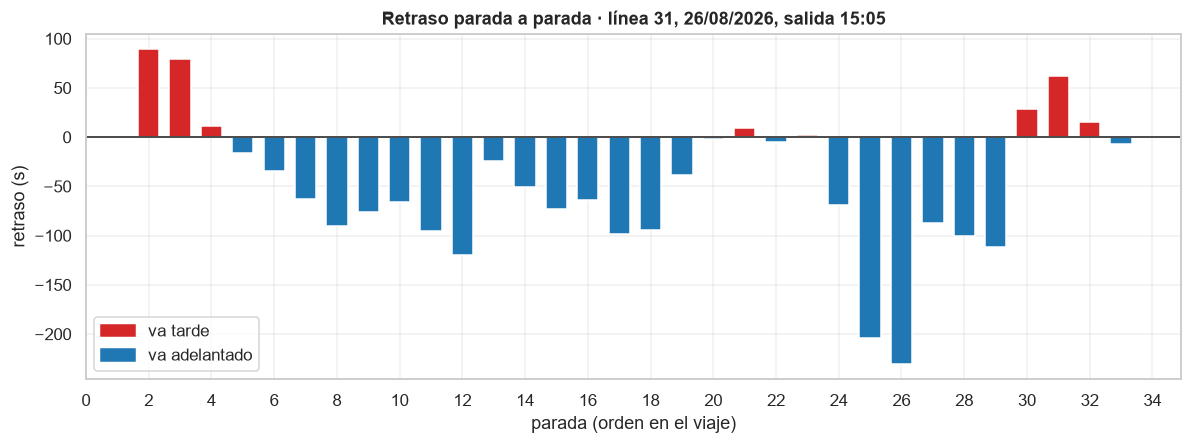

In [15]:
d = res.dropna(subset=["retraso_s"])
# Polaridad, no identidad: dos polos y un cero neutro. Adelanto en azul, retraso en rojo.
colores = np.where(d.retraso_s >= 0, PALETA["trafico_estado"], PALETA["emt_buses"])

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.bar(d.stop_sequence, d.retraso_s, color=colores, width=0.68)
ax.axhline(0, color="0.25", lw=1.2)
ax.set_xlabel("parada (orden en el viaje)")
ax.set_ylabel("retraso (s)")
ax.set_title(f"Retraso parada a parada · línea {LINEA}, {DIA:%d/%m/%Y}, salida 15:05")
ax.set_xticks(range(0, 35, 2))

manos = [
    plt.Rectangle((0, 0), 1, 1, color=PALETA["trafico_estado"]),
    plt.Rectangle((0, 0), 1, 1, color=PALETA["emt_buses"]),
]
ax.legend(manos, ["va tarde", "va adelantado"], loc="lower left", frameon=True)
plt.tight_layout()
plt.show()

El autobús sale de cabecera con **+89 s**, recupera en la Malva-rosa, va adelantado la
mayor parte del recorrido —hasta **−230 s** en Carrer de la Pau— y llega a Sorolla
prácticamente en hora.

Que la mediana sea **negativa** (−57 s) no es un fallo del cálculo: es agosto, sin
tráfico y sin colegios, y el horario está dimensionado para un mes normal. Lo confirma
el perfil: los adelantos se acumulan en el tramo central, el de Blasco Ibáñez, que en
septiembre es justo donde se pierde tiempo.

**Esto tiene una consecuencia para el modelado.** La variable objetivo no es «retraso»
sino *desviación respecto al horario*, y su distribución no está centrada en cero ni es
simétrica. Un baseline de «retraso = 0» no es tan malo como suena, y hay que medirlo
antes de presumir de nada.

---

## 8 · Hallazgos

1. **`shape_dist_traveled` no es distancia: es el horario reescalado.** $R^2 = 1{,}00000$
   contra los segundos programados en los 300 viajes de la muestra, con constante propia
   por viaje (6,7–20,5 u/s). Usarlo como eje habría hecho circular el cálculo del
   retraso, sin lanzar ningún error. Candidato claro a ficha de trampa.
2. **La geometría de `shapes.txt` sí es buena.** Las 34 paradas del sentido caen a
   mediana 3,4 m del trazado (máximo 15,1 m), y las 182 posiciones del vehículo a
   mediana 1,8 m. Recalcular la abscisa por proyección es barato y fiable.
3. **Trayectoria ≠ viaje.** El vehículo pasa 44 de sus 94 minutos parado en cabecera.
   La segmentación en viajes es un paso propio del etiquetado.
4. **La asignación de viaje fuera de punta es inequívoca**: 421 s de margen entre el
   primer y el segundo candidato. En hora punta, con intervalos de 4 min, ese margen se
   estrecha hasta ser el riesgo dominante del método.
5. **El retraso mediano en agosto es negativo** (−57 s en este viaje, con adelantos de
   hasta −230 s). La etiqueta es desviación con signo, no retraso, y el baseline del
   horario teórico parte con ventaja.
6. **`trips.txt` no trae `direction_id`** y `route_short_name` se repite en `73`, `C2` y
   `C3`. El enganche entre la capa en vivo y el GTFS es por texto o por geometría, nunca
   por clave.

Lo que de aquí merezca quedar fichado va a `docs/bitacora/`, `.claude/trampas/` o
`docs/07_decisiones.md` según la tabla de encaminamiento de `docs/bitacora/README.md`.